### **Maestrıa en Ciencias de Datos**
### **Examen 1 - Matematicas Aplicadas en Ciencia de Datos**
### **Profesor: Diego Fernando Fonseca Valero**

#### **Integrantes:**

| **Nombres** | **Codigo Estudiante** | **Cedula** |
|----------|----------|----------|
|Eduardo Andres Piñeros Manjarres  | 1000269688  | 1067841294  |
|Natalia Ceballos Posada           | 1000270186  | 1034987681  |


In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

### **Ejercicio 1**

In [2]:
### Datos Tecnicos

## Matriz de Codificacion (A)
a = sp.symbols('a')
A = sp.Matrix([
    [1, 2, 1],
    [a, 4, 1],
    [2, 1, 3]
])

## Tabla de Conversion
tabla = {
 1: 'A',
 2: 'B',
 3: 'C',
 4: 'D',
 5: 'E',
 6: 'F',
 7: 'G',
 8: 'H',
 9: 'I',
 10: 'J',
 11: 'K',
 12: 'L',
 13: 'M',
 14: 'N',
 15: 'O',
 16: 'P',
 17: 'Q',
 18: 'R',
 19: 'S',
 20: 'T',
 21: 'U',
 22: 'V',
 23: 'W',
 24: 'X',
 25: 'Y',
 26: 'Z',
 27: ' '
 }

## La Transmision Interceptada (Vectores y)
y = sp.Matrix([
    [56, 67, 103],
    [54, 11, 117],
    [77, 55, 136],
    [70, 95, 110],
    [87, 77, 136],
    [96, 111, 138]
    ])

In [3]:
### (a) Plantee una ecuaci´on matem´atica que relacione el determinante de A con el factor de volumen

alpha = sp.solve(sp.Eq(A.det(),15)) 

A2= A.subs(a,alpha[0])

A2.det()

15

In [4]:
inversa = A2.inv()
messages = []
for i in range(y.shape[0]):
    fila = y.row(i)
    solutions = A2.solve(fila.T)
    message = map(lambda x: tabla[round(x)],solutions)
    messages.extend(list(message))

In [5]:
messages
print(''.join(messages))

EL TEXTO ES TUYO  


### **Ejecrcicio 2**

In [6]:
# matriz de  transicion 
P = np.array([
    [0.95, 0.05, 0, 0, 0, 0, 0],
    [0.4, 0.3, 0.3, 0, 0, 0, 0],
    [0, 0.45, 0.1, 0.45, 0, 0, 0],
    [0, 0, 0.4, 0.2, 0.4, 0, 0],
    [0, 0, 0, 0.45, 0.1, 0.45, 0],
    [0, 0, 0, 0, 0.3, 0.3, 0.4],
    [0, 0, 0, 0, 0, 0.05, 0.95],
])

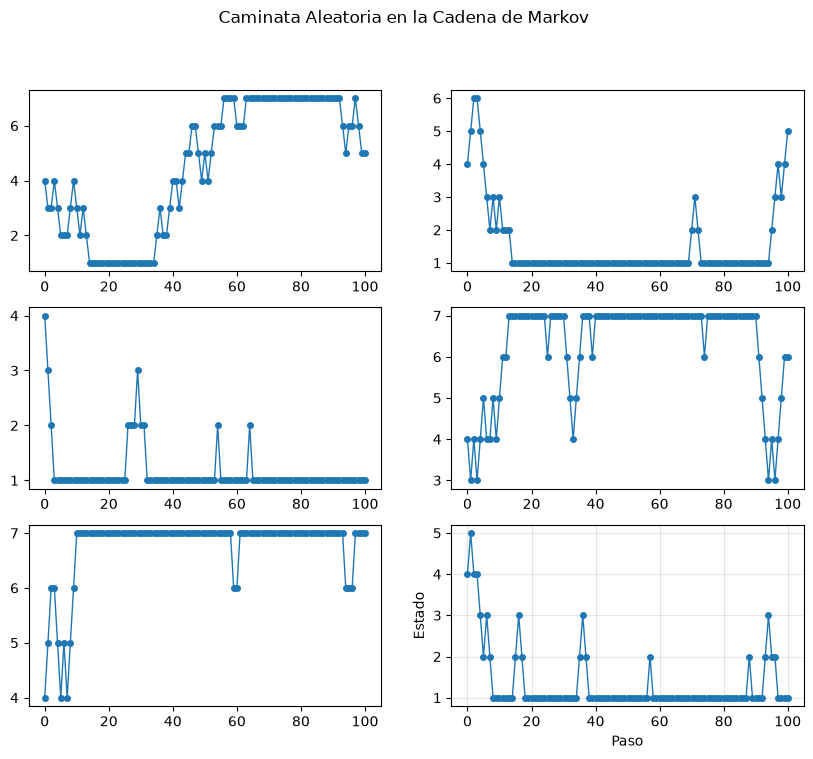

In [7]:
fig, axes = plt.subplots(nrows=3, ncols=2,figsize=(10,8))
for i,ax in enumerate(axes.flat):
    estado = 3      # índice 3 = estado 4
    caminata = [estado + 1]
    for _ in range(100):
        estado = np.random.choice(7, p=P[estado])
        caminata.append(estado + 1)
    ax.plot(caminata, marker='o', linestyle='-', linewidth=1, markersize=4)
plt.xlabel('Paso')
plt.ylabel('Estado')
fig.suptitle('Caminata Aleatoria en la Cadena de Markov')
plt.grid(True, alpha=0.3)
plt.show()

### **Ejercicio 3**


In [ ]:
img = Image.open(r'..\Imagen\gato_imagen.jpg').convert("L")
ancho, alto = img.size

alpha=0.8
n_iteraciones=20

X = np.array(img)      

for n in range(n_iteraciones):
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            arriba = X[i][j-1]
            abajo = X[i][j+1]
            der = X[i+1][j]
            izq = X[i-1][j]
            X[i][j] = alpha * X[i][j] + (1 - alpha) / 4 * (arriba + abajo + izq + der)
X_uint8 = np.clip(X, 0, 255).astype(np.uint8)
img_resultado = Image.fromarray(X_uint8)  
img_resultado.save(f'../Imagen/img{n}.png')

   


# Image.fromarray(X0).save("original.png")
# Image.fromarray(bordes).save("bordes.png")



C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15652\1125771276.py:13: RuntimeWarning: overflow encountered in scalar add
  abajo = X[i][j+1]


KeyboardInterrupt: 

In [22]:
def iterar_punto_fijo(X0, alpha, tol=1e-6, max_iter=5000):
    """
    Itera X^(n+1) = alpha*X^(n) + (1-alpha)/4 * (suma de 4 vecinos)
    hasta que el cambio relativo entre iteraciones (norma de Frobenius) sea < tol.
    Devuelve la imagen suavizada final y la lista de errores por iteracion.
    """
    X = X0.astype(float).copy()
    errores = []
    for n in range(max_iter):
        Xp = np.pad(X, 1, mode='edge')                       # condicion de frontera: replicar borde
        vecinos = Xp[2:,1:-1] + Xp[:-2,1:-1] + Xp[1:-1,2:] + Xp[1:-1,:-2]   # sin bucles for
        X_new = alpha*X + (1-alpha)/4*vecinos
        # Metrica de convergencia: cambio relativo en norma de Frobenius
        err = np.linalg.norm(X_new - X) / np.linalg.norm(X)
        errores.append(err)
        X = X_new
        if err < tol:
            break
    return X, np.array(errores)

Convergio en 3000 iteraciones (tol=1e-6)


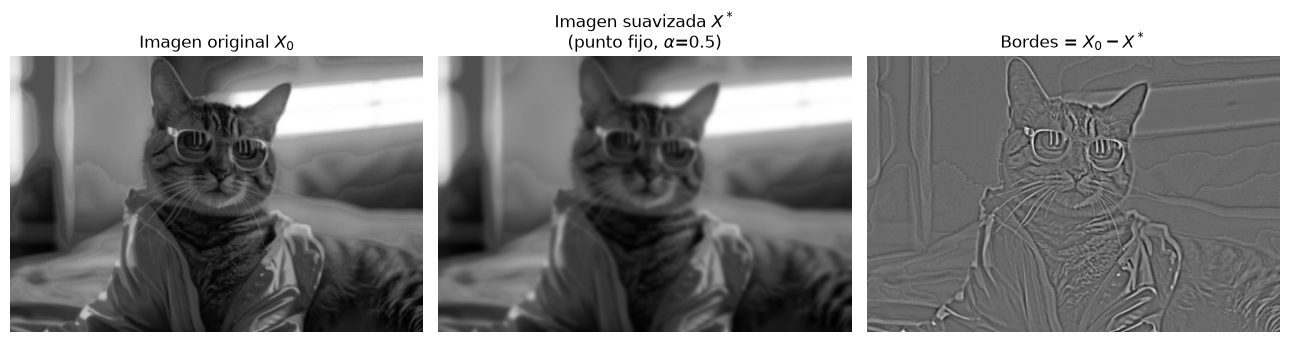

In [26]:
X_suave, errores = iterar_punto_fijo(X, alpha=0.99, tol=1e-6, max_iter=3000)
bordes = X - X_suave

print(f"Convergio en {len(errores)} iteraciones (tol=1e-6)")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
axes[0].imshow(X, cmap='gray'); axes[0].set_title("Imagen original $X_0$"); axes[0].axis('off')
axes[1].imshow(X_suave, cmap='gray'); axes[1].set_title(f"Imagen suavizada $X^*$\n(punto fijo, $\\alpha$=0.5)"); axes[1].axis('off')
axes[2].imshow(bordes, cmap='gray'); axes[2].set_title("Bordes = $X_0 - X^*$"); axes[2].axis('off')
plt.tight_layout()
plt.savefig("ejercicio3_bordes.png", dpi=110)
plt.show()